In [51]:
### CNN for the mnist dataset

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)

dir(mnist)

(60000, 28, 28)
(60000,)


['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_data']

In [23]:
labels = list(range(0,10))
print(labels)

def plot(X, y, idx):
    plt.imshow(X[idx])
    plt.xlabel(labels[[y[idx]][0]])
    

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


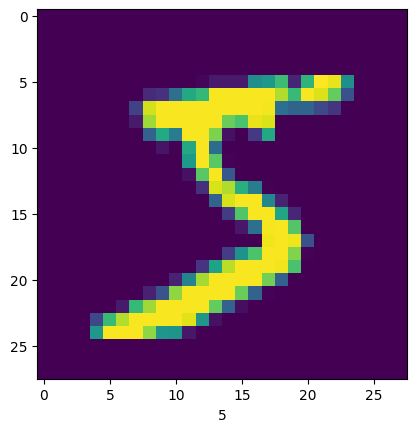

In [24]:
plot(X_train, y_train, 0)

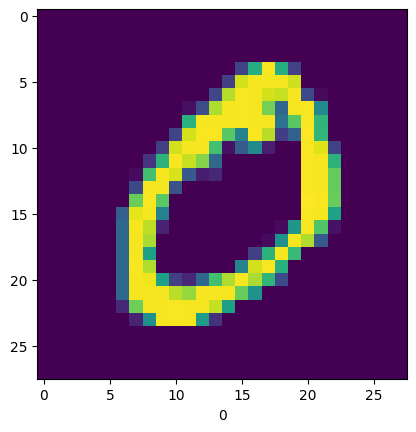

In [27]:
plot(X_train, y_train, 1)

In [30]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [33]:
X_train.shape

(60000, 28, 28)

In [35]:
model = keras.models.Sequential([
    #CNN - feature extraction
    keras.layers.Conv2D(filters=30, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    #Dense - classifier
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9560 - loss: 0.1462
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9847 - loss: 0.0507
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9887 - loss: 0.0352
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9912 - loss: 0.0265
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9935 - loss: 0.0205
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9951 - loss: 0.0157
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9957 - loss: 0.0127
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9965 - loss: 0.0098
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9967 - loss: 0.0089
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9966 - loss: 0.0076


In [36]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9909 - loss: 0.0353


[0.03532137721776962, 0.9908999800682068]

In [40]:
preds = model.predict(X_test)
predictions = [np.argmax(prob) for prob in preds ]
predictions[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

prediction:  7


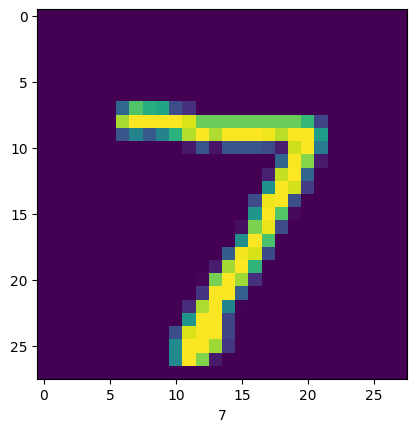

In [45]:
print("prediction: " ,predictions[0])
plot(X_test, y_test, 0)


In [49]:
cf = classification_report(y_test, predictions)
print(cf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Text(50.722222222222214, 0.5, 'truth')

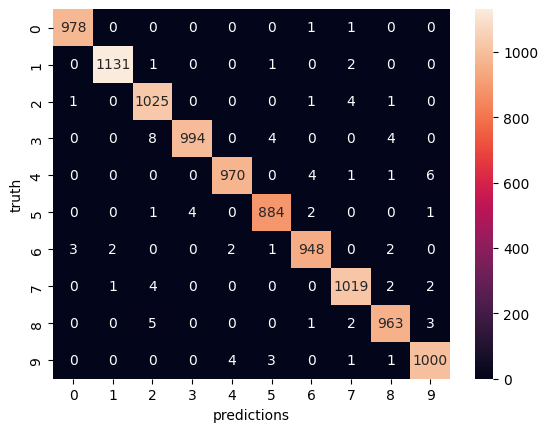

In [55]:
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.xlabel("predictions")
plt.ylabel("truth")